In [2]:
!pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached numba-0.64.0-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached msgpack-1.1.2-cp311-cp311-win_amd64.whl.metadata (8.4 kB)
  Using cached llvmlite-0.46.0-cp311-cp311-win_amd64.whl.metadata (4.9 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached msgpack-1.1.2-cp311-cp311-win_amd64.whl (71 kB)
Using cached numba-0.64.0-cp311-cp311-win_amd64.whl (2.7 MB)
Using cached llvmlite-0.46.0-cp311-cp311-win_amd64.whl (38.1 MB)
Using cached pooch-1.9.0-p


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2
import librosa


In [23]:
label = {'eight':8,
        'five':5,
        'four':4,
        'nine':9,
        'one':1,
        'seven':7,
        'six':6,
        'three':3,
        'two':2,
        'zero':0}

In [24]:
MAX_LEN = 128

def pad_spectrogram(spec):

    if spec.shape[1] < MAX_LEN:
        pad_width = MAX_LEN - spec.shape[1]
        spec = np.pad(spec, ((0,0),(0,pad_width)))

    else:
        spec = spec[:, :MAX_LEN]

    return spec

In [25]:
X = []
y = []
for i in os.listdir('Digits/'):
    for j in os.listdir(f'Digits/{i}/'):
        try:
            audio_path = f'Digits/{i}/{j}'
            signal, sr = librosa.load(audio_path, sr=16000)
            
            mel_spec = librosa.feature.melspectrogram(
                y=signal,
                sr=sr,
                n_mels=128,
                hop_length=512,
                n_fft=2048
            )
            
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            voice_array = pad_spectrogram(mel_spec_db)
            voice_array = voice_array.reshape(128, 128, 1)
            X.append(voice_array)
            y.append(label[i])
        except:
            continue
X = np.array(X)
y = np.array(y)

In [26]:
X.shape

(17000, 128, 128, 1)

In [27]:
y.shape

(17000,)

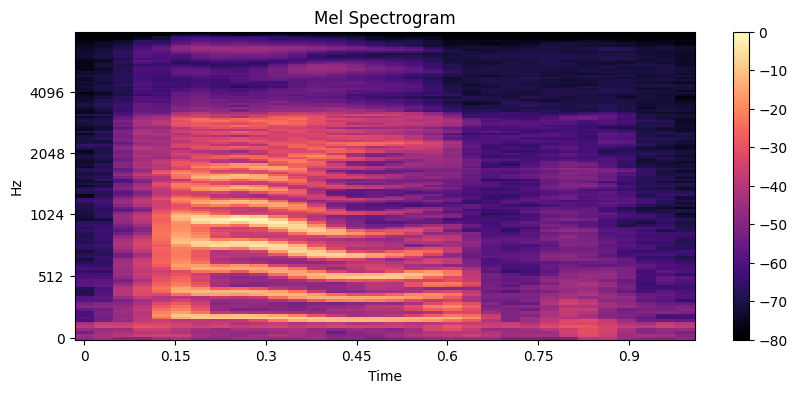

In [8]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

In [29]:
from keras.utils import to_categorical

In [30]:
y = to_categorical(y, num_classes=10)

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [33]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

In [36]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units=60, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

C:\Users\ASUS\Desktop\ML_18-35_Hrach\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)

Epoch 1/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 71s 186ms/step - accuracy: 0.4343 - loss: 1.5775 - val_accuracy: 0.6502 - val_loss: 0.9834
Epoch 2/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 69s 185ms/step - accuracy: 0.7398 - loss: 0.7534 - val_accuracy: 0.7290 - val_loss: 0.7605
Epoch 3/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 69s 185ms/step - accuracy: 0.8011 - loss: 0.5904 - val_accuracy: 0.8010 - val_loss: 0.5820
Epoch 4/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 82s 185ms/step - accuracy: 0.8467 - loss: 0.4650 - val_accuracy: 0.8245 - val_loss: 0.5099
Epoch 5/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 69s 185ms/step - accuracy: 0.8674 - loss: 0.3945 - val_accuracy: 0.8280 - val_loss: 0.5156


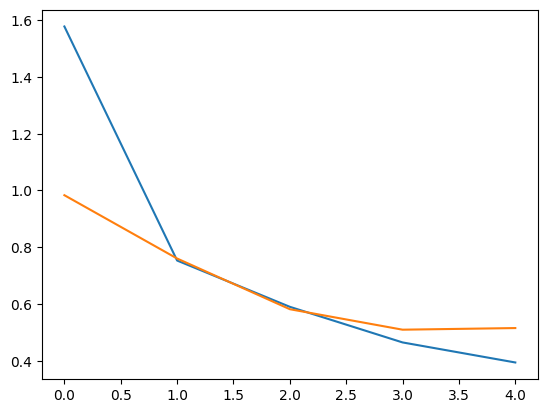

In [38]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

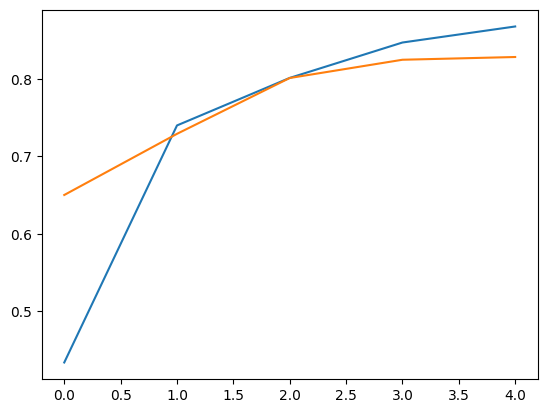

In [39]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [40]:
audio_path = "audio_clip_2026-03-12_20-02-30-117.wav"
signal, sr = librosa.load(audio_path, sr=16000)

mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128,
    hop_length=512,
    n_fft=2048
)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
voice_array = pad_spectrogram(mel_spec_db)
voice_array = voice_array.reshape(1, 128, 128, 1)

In [42]:
np.argmax(model.predict(voice_array))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


np.int64(4)

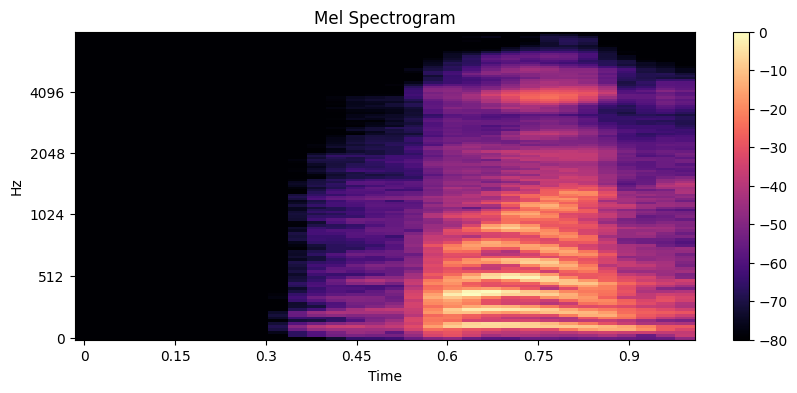

In [44]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

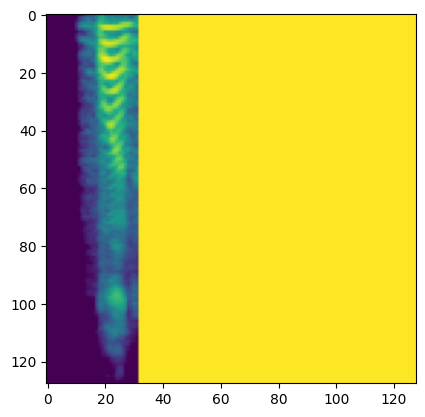

In [43]:
plt.imshow(voice_array.reshape(128, 128, 1))